# Multimodal search bar — spec §7

Search a word and get back two things: how present it is in the corpus, and
**what the speaker's body and voice were doing while saying it** — shot, pitch,
wrist velocity — with the same query run automatically on the other corpus
through a curated concept mapping.

| here | spec | note |
|---|---|---|
| 1–2 | §7.1 | three separate temporal rules, one per modality |
| 3 | §7.2 | three-tier reliability display; never a % without its n |
| 4–5 | §7.4 | concordance and collocates, reusing the Verbal Language logic |
| 6 | §7.3 | EN–ZH concept mapping, aggregate plus per-variant |

## Why this is a word-level notebook, not a window-level one

Every other notebook here works on 5-second windows. A window spans roughly
fifteen words, so it cannot answer "what was her pitch while she said
*rights*" — the question this feature exists for. Three stored signals make the
word-level version possible:

* **word timestamps** — `verbal.tokens`, per word, from the recogniser
* **dense prosody** — f0 and intensity at a 10 ms hop
  (`scripts/backfill_dense_prosody.py`)
* **dense gesture** — wrist speed from pose keyframes at ~10 Hz

Dense prosody is backfilled for all 39 Ted videos and 1 of 29 YiXi videos, so
pitch is available for the English corpus and largely missing for the Chinese
one until the rest are processed. Everything else works for both.

In [1]:
import os, sys, warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd() if Path.cwd().name == "notebooks" else Path.cwd() / "notebooks"))
warnings.filterwarnings("ignore", category=RuntimeWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
import _corpus as C

pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 9})

CJK = ["Noto Sans CJK SC", "Noto Sans CJK TC", "Source Han Sans SC", "WenQuanYi Zen Hei"]
_av = {f.name for f in font_manager.fontManager.ttflist}
_ch = next((f for f in CJK if f in _av), None)
if _ch:
    plt.rcParams["font.sans-serif"] = [_ch] + list(plt.rcParams["font.sans-serif"])
    plt.rcParams["axes.unicode_minus"] = False

# ── §7.1: every temporal parameter is a named constant ──────────────────
# "All three parameters (margin, +/-0.5 s, etc.) should be configurable
#  constants, so they can be re-tuned after validation without changing the
#  underlying logic."
PITCH_MARGIN_S   = 0.175   # spec: 150-200ms either side of the word
GESTURE_HALF_S   = 0.50    # spec: +/-0.5s, gesture is not synchronous with speech
# Shot is deliberately NOT a window: it is a point lookup of the segment
# containing the word's own timestamp.

# ── §7.2: the reliability tiers ─────────────────────────────────────────
TIER_LOW, TIER_MID = 5, 15

# ── §7.4 ────────────────────────────────────────────────────────────────
KWIC_WIDTH     = 6   # words either side; user-adjustable per the spec
COLLOCATE_SPAN = 5   # +/-5 words

CORPUS_A, CORPUS_B = "Ted", "YiXi"
COLOUR = {CORPUS_A: "#C84B31", CORPUS_B: "#1B4F8A"}
print("corpora:", C.available_corpora())

corpora: ['TedX', 'Yixi']


## 1. The word index  — §7.1

Rather than recomputing signals per query, every word in a corpus is enriched
**once** with the three modality lookups, each on its own temporal rule:

| modality | rule | why not a single window |
|---|---|---|
| pitch | word start/end ± 175 ms | intonation can precede or extend past the phonetic boundary |
| gesture | word midpoint ± 0.5 s | gesture-speech co-occurrence is not synchronous; strokes often begin early |
| shot / angle | point lookup at the word's timestamp | a shot is a segment, not a window — asking "which window" would blur across cuts |

Pitch is expressed in **semitones from that speaker's own median**, and both
pitch and gesture are binned into **tertiles within the speaker**, so "high"
means high for them. A single corpus-wide threshold would mostly sort speakers
by vocal tract and body size.

Building the index costs a few minutes per corpus and is cached on disk. Every
search afterwards is a filter over a table.

**Which tokenisation.** Words come from the stored *segmented* tokens — spaCy's
tokenisation, with timings mapped back onto the recogniser's output — not from
the recogniser's own tokens. The distinction is invisible in English and fatal
in Chinese: SenseVoice emits roughly one token per Han character, so an index
built from it contains 女 and 性 but never 女性, and a search for 婚姻 returns
zero rather than failing loudly. Using the segmented stream also puts this
notebook on the same tokenisation as the word list, collocations and the word
sketch, so no two parts of the system can disagree about what a word is.

In [2]:
CACHE = Path(os.environ.get("WORK_DIR", "/tmp/mannerism")) / "search_index"


def _per_word_signal(ts, values, starts, ends):
    """Mean of `values` between each (start, end) pair. NaN-safe, vectorised."""
    out = np.full(len(starts), np.nan)
    if len(ts) == 0:
        return out
    lo = np.searchsorted(ts, starts, side="left")
    hi = np.searchsorted(ts, ends, side="right")
    for i, (a, b) in enumerate(zip(lo, hi)):
        if b > a:
            seg = values[a:b]
            seg = seg[~np.isnan(seg)]
            if len(seg):
                out[i] = seg.mean()
    return out


def build_word_index(corpus, refresh=False, progress=True):
    """Every word in the corpus with its pitch, gesture and shot attached."""
    from tqdm.auto import tqdm

    videos = C.load_videos(corpus)
    windows = C.load_windows(corpus)
    segs = C.shot_segments(corpus)

    CACHE.mkdir(parents=True, exist_ok=True)
    key = f"{corpus}_{len(videos)}_{len(windows)}_seg2"  # spaCy tokenisation, _clean_word normalisation
    cache_file = CACHE / f"{key}.pkl"
    if cache_file.exists() and not refresh:
        if progress:
            print(f"loaded from cache: {cache_file}")
        return pd.read_pickle(cache_file)

    frames, fell_back = [], []
    for jid in tqdm(list(videos.job_id), desc=f"indexing {corpus}", disable=not progress):
        # spaCy's tokenisation, not the recogniser's. For Chinese the ASR emits
        # roughly one token per character, so an index built from it holds 女
        # and 性 separately, never 女性, and every Chinese query returns nothing
        # at all rather than failing loudly. See _corpus.segmented_tokens.
        words = C.segmented_tokens(corpus, jid)
        if words.empty:
            words = C.word_tokens(corpus, jid)
            if not words.empty:
                fell_back.append(jid)
        if words.empty:
            continue
        words = words.sort_values("start_s").reset_index(drop=True)
        words["job_id"] = jid
        mid = (words.start_s + words.end_s) / 2

        # ── pitch: the word's own span, plus the spec's margin ───────────
        dense = C.dense_prosody(corpus, jid)
        if not dense.empty:
            ts = dense.ts.to_numpy()
            f0 = dense.f0.to_numpy(dtype=float)
            f0_word = _per_word_signal(ts, f0,
                                       (words.start_s - PITCH_MARGIN_S).to_numpy(),
                                       (words.end_s + PITCH_MARGIN_S).to_numpy())
            base = np.nanmedian(f0)
            words["pitch_st"] = 12 * np.log2(f0_word / base) if base and base > 0 else np.nan
            words["intensity_db"] = _per_word_signal(
                ts, dense.intensity_db.to_numpy(dtype=float),
                (words.start_s - PITCH_MARGIN_S).to_numpy(),
                (words.end_s + PITCH_MARGIN_S).to_numpy())
        else:
            words["pitch_st"] = np.nan
            words["intensity_db"] = np.nan

        # ── gesture: the spec's +/-0.5s, not the word's own span ─────────
        speed = C.wrist_speed_series(corpus, jid).dropna(subset=["speed"])
        if not speed.empty:
            words["wrist_speed"] = _per_word_signal(
                speed.ts.to_numpy(), speed.speed.to_numpy(dtype=float),
                (mid - GESTURE_HALF_S).to_numpy(), (mid + GESTURE_HALF_S).to_numpy())
        else:
            words["wrist_speed"] = np.nan

        # ── shot: a point lookup into the segment containing the word ────
        vs = segs[segs.job_id == jid].sort_values("start_s")
        if not vs.empty:
            idx = np.searchsorted(vs.start_s.to_numpy(), mid.to_numpy(), side="right") - 1
            idx = np.clip(idx, 0, len(vs) - 1)
            words["shot_type"] = vs.shot_type.to_numpy()[idx]
        else:
            words["shot_type"] = None

        # ── angles are only classified per window ────────────────────────
        vw = windows[windows.job_id == jid].sort_values("start_s")
        if not vw.empty:
            widx = np.searchsorted(vw.start_s.to_numpy(), mid.to_numpy(), side="right") - 1
            widx = np.clip(widx, 0, len(vw) - 1)
            for col in ("horizontal_angle", "vertical_angle"):
                words[col] = vw[col].to_numpy()[widx]

        # ── tertiles within the speaker ──────────────────────────────────
        for src, dst, labels in [("pitch_st", "pitch_level", ["low", "mid", "high"]),
                                 ("wrist_speed", "gesture_bin", ["low", "mid", "high"])]:
            s = words[src]
            words[dst] = (pd.qcut(s, 3, labels=labels, duplicates="drop")
                          if s.notna().sum() > 30 else None)

        frames.append(words)

    if fell_back:
        print(f"WARNING — {len(fell_back)} video(s) had no stored segmented tokens "
              f"and fell back to recogniser tokens. For Chinese those are "
              f"characters, so word searches will miss them entirely: "
              + ", ".join(fell_back[:5]) + (" ..." if len(fell_back) > 5 else ""))

    index = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
    if not index.empty:
        # Normalised through the same helper the word list uses, so a form in
        # flags/concepts_en_zh.yaml matches identically in both places. Note it
        # deliberately does NOT strip apostrophes: "'s" must stay "'s" rather
        # than collapsing to a bare "s" that collides with the letter.
        from core import corpus_analysis
        index["word_lc"] = index.word.astype(str).str.lower().map(corpus_analysis._clean_word)

        # `is_word` marks the tokens the word list counts — alphabetic after
        # cleaning, so contraction fragments ("n't", "'s") and numerals are
        # excluded. They stay in the index because concordance lines need them
        # to read correctly, but rates are computed over is_word only, so a
        # figure here shares its denominator with notebooks 01 and 03 instead
        # of sitting 3% above them.
        index["is_word"] = index.word_lc.str.isalpha().fillna(False)
        index = index.merge(videos[["job_id", "label"]], on="job_id", how="left")
        pd.to_pickle(index, cache_file)
        if progress:
            print(f"cached to {cache_file}")
    return index


IDX = {CORPUS_A: build_word_index(CORPUS_A), CORPUS_B: build_word_index(CORPUS_B)}
print(f"\n{CORPUS_A}: {len(IDX[CORPUS_A]):,} words, "
      f"{IDX[CORPUS_A].job_id.nunique()} videos")
print("coverage — pitch %.0f%%, gesture %.0f%%, shot %.0f%%" % (
    100 * IDX[CORPUS_A].pitch_st.notna().mean(),
    100 * IDX[CORPUS_A].wrist_speed.notna().mean(),
    100 * IDX[CORPUS_A].shot_type.notna().mean()))
print(f"\n{CORPUS_B}: {len(IDX[CORPUS_B]):,} words, "
      f"{IDX[CORPUS_B].job_id.nunique()} videos")
print("coverage — pitch %.0f%%, gesture %.0f%%, shot %.0f%%" % (
    100 * IDX[CORPUS_B].pitch_st.notna().mean(),
    100 * IDX[CORPUS_B].wrist_speed.notna().mean(),
    100 * IDX[CORPUS_B].shot_type.notna().mean()))

/home/abx13/Prog/Mannerism-Analyzer/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


indexing TedX:   0%|          | 0/39 [00:00<?, ?it/s]

2026-09-25 02:25:10.361 | INFO     | core.results_repository:__init__:199 - [repo] 5 MongoDB shards, fill order: multiarth-cluster-1.rx35xvv.mongodb.net, cluster0.axiwkps.mongodb.net, mutliarth-cluster.7lduqij.mongodb.net, multiarth-cluster-1.wwaqwip.mongodb.net, multiarth-cluster-1.kliir9n.mongodb.net


indexing TedX:   3%|▎         | 1/39 [00:16<10:11, 16.10s/it]

indexing TedX:   5%|▌         | 2/39 [00:25<07:40, 12.44s/it]

...

indexing Yixi:  93%|█████████▎| 27/29 [04:25<00:02,  1.17s/it]

indexing Yixi:  97%|█████████▋| 28/29 [04:26<00:01,  1.23s/it]

indexing Yixi: 100%|██████████| 29/29 [04:27<00:00,  1.12s/it]

indexing Yixi: 100%|██████████| 29/29 [04:27<00:00,  9.22s/it]

cached to /home/abx13/.local/share/mannerism/search_index/Yixi_29_10829_seg2.pkl

TedX: 68,623 words, 39 videos
coverage — pitch 100%, gesture 91%, shot 94%

Yixi: 146,548 words, 29 videos
coverage — pitch 99%, gesture 90%, shot 93%


## 2. Searching  — §7.2

`search()` returns every occurrence of a term with its three modality readings
attached. `profile()` summarises those occurrences, and applies the reliability
rule the spec is emphatic about:

> Core principle: never display a percentage without also showing the
> underlying absolute n, so a result based on 2 occurrences is never presented
> on par with one based on 50.

The three tiers are thresholds you can move — the spec calls 5 and 15
"indicative starting points", to be tuned once you see how the corpus'
vocabulary actually distributes.

In [3]:
def search(term, corpus=CORPUS_A, index=None):
    """Every occurrence of *term*, with its modality readings."""
    idx = index if index is not None else IDX[corpus]
    return idx[idx.word_lc == term.lower().strip()]


def tier_of(n):
    if n < TIER_LOW:
        return "insufficient — counts only"
    if n < TIER_MID:
        return "low reliability"
    return "reliable"


def profile(term, corpus=CORPUS_A, index=None):
    """The spec's headline result: presence, plus the three distributions."""
    idx = index if index is not None else IDX[corpus]
    hits = search(term, corpus, idx)
    n = len(hits)
    # Denominator is the word-count, not the row-count: the index also holds
    # contraction fragments and numerals so that concordance lines read
    # correctly, and counting those would inflate the base ~3% relative to
    # every other notebook.
    n_words = int(idx.is_word.sum()) if "is_word" in idx.columns else len(idx)
    out = {
        "term": term, "corpus": corpus, "n": n,
        "tier": tier_of(n),
        "per_10k_words": round(n / n_words * 10_000, 2) if n_words else 0.0,
        "videos": int(hits.job_id.nunique()),
        "video_range_pct": round(100 * hits.job_id.nunique() / idx.job_id.nunique(), 1)
                           if len(idx) else 0.0,
    }
    for col in ("shot_type", "pitch_level", "gesture_bin"):
        # Percentages are over the occurrences this modality could be measured
        # for, which is not always n: a word spoken off-camera has no shot, and
        # an unvoiced one has no pitch. That denominator is reported alongside
        # rather than left implicit, since a share of 6 shown under a headline
        # n of 10 is exactly the kind of mismatch §7.2 is guarding against.
        vc = hits[col].value_counts()
        vc = vc[vc > 0]                      # qcut categories with no hits
        measured = int(vc.sum())
        out[col] = {k: (int(v), round(100 * v / measured, 1)) for k, v in vc.items()}
        out[f"{col}_n"] = measured
    return out


def show_profile(term, corpus=CORPUS_A, index=None):
    p = profile(term, corpus, index)
    banner = {"insufficient — counts only": "!! ", "low reliability": " ~ ", "reliable": "   "}[p["tier"]]
    print(f"{banner}'{p['term']}' in {p['corpus']}:  n={p['n']}  "
          f"({p['per_10k_words']} per 10k words)  in {p['videos']} videos "
          f"({p['video_range_pct']}% of the corpus)   [{p['tier']}]")
    if p["n"] < TIER_LOW:
        print("    counts only — too few occurrences for percentages to mean anything")
    for col in ("shot_type", "pitch_level", "gesture_bin"):
        if not p[col]:
            print(f"    {col:<12} not measurable for any occurrence")
            continue
        measured = p[f"{col}_n"]
        # Gate on this modality's own n, not the headline n.
        show_pct = measured >= TIER_LOW
        parts = [f"{k} {v[0]}" + (f" ({v[1]}%)" if show_pct else "")
                 for k, v in sorted(p[col].items(), key=lambda kv: -kv[1][0])]
        suffix = f"   [of {measured} measured]" if measured != p["n"] else ""
        print(f"    {col:<12} " + "  ".join(parts) + suffix)
    return p


for term in ["women", "feminism", "power", "intersectionality"]:
    show_profile(term)
    print()

   'women' in TedX:  n=421  (63.21 per 10k words)  in 38 videos (97.4% of the corpus)   [reliable]
    shot_type    close_up 220 (56.7%)  medium_close 71 (18.3%)  long 54 (13.9%)  very_long 26 (6.7%)  medium 9 (2.3%)  medium_long 7 (1.8%)  extreme_close_up 1 (0.3%)   [of 388 measured]
    pitch_level  low 155 (36.8%)  high 134 (31.8%)  mid 132 (31.4%)
    gesture_bin  low 125 (33.7%)  mid 123 (33.2%)  high 123 (33.2%)   [of 371 measured]

!! 'feminism' in TedX:  n=4  (0.6 per 10k words)  in 3 videos (7.7% of the corpus)   [insufficient — counts only]
    counts only — too few occurrences for percentages to mean anything
    shot_type    close_up 2  long 1  very_long 1
    pitch_level  low 4
    gesture_bin  high 3  low 1

   'power' in TedX:  n=52  (7.81 per 10k words)  in 14 videos (35.9% of the corpus)   [reliable]
    shot_type    close_up 26 (51.0%)  medium_close 16 (31.4%)  long 9 (17.6%)   [of 51 measured]
    pitch_level  mid 23 (44.2%)  low 15 (28.8%)  high 14 (26.9%)
    gestu

### The distributions, against the corpus baseline

A keyword's shot distribution means nothing on its own — if 45% of all Ted
words are spoken in close-up, then a keyword at 45% close-up is unremarkable.
What matters is the **difference from the corpus baseline**, which is what this
plots.

In [4]:
l = ['这个']

for i in l:
    print(i in IDX[CORPUS_B].word_lc)

False


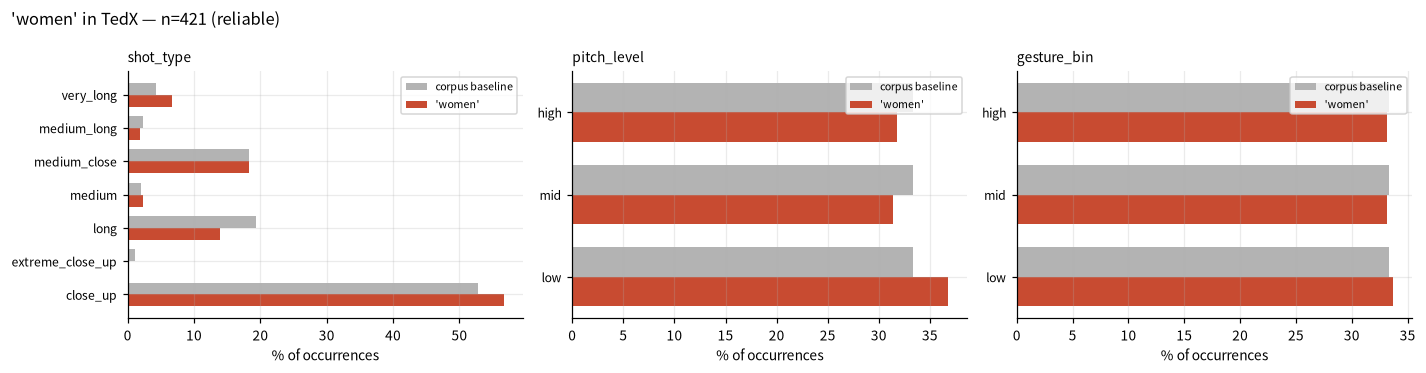

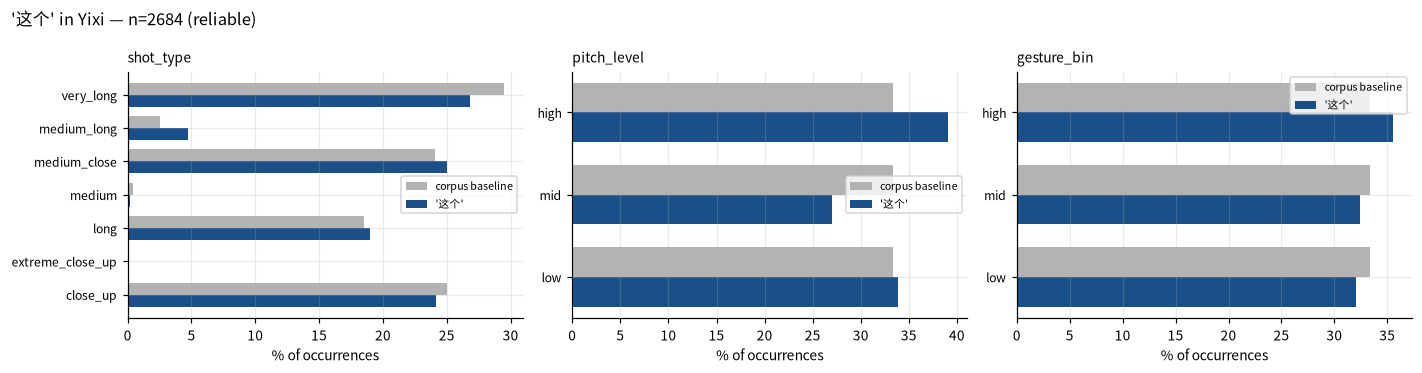

In [5]:
def profile_plot(term, corpus=CORPUS_A, index=None):
    idx = index if index is not None else IDX[corpus]
    hits = search(term, corpus, idx)
    if hits.empty:
        print(f"no occurrences of '{term}'"); return

    cols = [("shot_type", None), ("pitch_level", ["low", "mid", "high"]),
            ("gesture_bin", ["low", "mid", "high"])]
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
    for ax, (col, order) in zip(axes, cols):
        base = idx[col].value_counts(normalize=True) * 100
        kw = hits[col].value_counts(normalize=True) * 100
        cats = order or sorted(set(base.index) | set(kw.index))
        base = base.reindex(cats).fillna(0)
        kw = kw.reindex(cats).fillna(0)
        y = np.arange(len(cats))
        ax.barh(y + 0.18, base, height=0.36, color="0.7", label="corpus baseline")
        ax.barh(y - 0.18, kw, height=0.36, color=COLOUR[corpus], label=f"'{term}'")
        ax.set_yticks(y, cats, fontsize=8)
        ax.set_xlabel("% of occurrences"); ax.set_title(col, loc="left", fontsize=9)
        ax.legend(fontsize=7)
    n = len(hits)
    fig.suptitle(f"'{term}' in {corpus} — n={n} ({tier_of(n)})", x=0.01, ha="left")
    plt.tight_layout(); plt.show()


profile_plot("women")
profile_plot("这个",corpus=CORPUS_B)

## 3. Concordance — KWIC  — §7.4

> for every occurrence of the searched keyword, show the context line: N words
> to the left + the keyword highlighted + N words to the right. Window size is
> user-adjustable in the interface (not a fixed default).

`KWIC_WIDTH` is that adjustable parameter. Context is assembled from the word
index itself, so the tokenisation is the same one every other number here
rests on.

In [6]:
def concordance(term, corpus=CORPUS_A, width=None, limit=15, index=None):
    width = width or KWIC_WIDTH
    idx = index if index is not None else IDX[corpus]
    hits = search(term, corpus, idx)
    rows = []
    for jid, g in hits.groupby("job_id"):
        video = idx[idx.job_id == jid].sort_values("start_s").reset_index(drop=True)
        pos = {s: i for i, s in enumerate(video.start_s)}
        for _, h in g.iterrows():
            i = pos.get(h.start_s)
            if i is None:
                continue
            left = " ".join(video.word[max(0, i - width):i])
            right = " ".join(video.word[i + 1:i + 1 + width])
            rows.append({
                "video": (h.label or jid)[:26],
                "t": f"{h.start_s:.1f}s",
                "left": left, "keyword": h.word, "right": right,
                "shot": h.shot_type, "pitch": h.pitch_level, "gesture": h.gesture_bin,
            })
    return pd.DataFrame(rows).head(limit)


display(concordance("women", width=7))

,video,t,left,keyword,right,shot,pitch,gesture
0,7 The revolutionary power,362.6s,in Istanbul an American scholar working on,women,writers in the Middle East came to,long,low,mid
1,7 The revolutionary power,523.4s,case I think it should concern us,women,more than men Because when societies slide,long,mid,high
2,7 The revolutionary power,532.8s,backwards into authoritarianism nationalism or...,women,have much more to lose That is,long,high,mid
3,7 The revolutionary power,1121.5s,and written extensively about minority rights ...,women,rights LGBT rights But as I was,very_long,mid,low
4,28 Dangerous times call fo,69.5s,the rise in sexism racism violence against,women,and girls and I 'm angry too,close_up,low,high
5,28 Dangerous times call fo,129.1s,the cultural construct that encourages us espe...,women,and girls to compete compare criticize We,long,mid,mid
6,28 Dangerous times call fo,149.9s,collective power as a global community of,women,and the men and the allies who,close_up,low,low
7,28 Dangerous times call fo,162.1s,are necessary to create a world where,women,and girls are safe in their homes,long,high,mid
8,28 Dangerous times call fo,192.9s,world we 're living longer than ever,Women,over 65 are among the fastest growing,close_up,high,high
9,28 Dangerous times call fo,212.4s,what a change this represents Post -Menopausal,women,like me not that long ago were,long,low,mid


## 4. Collocates — log-dice  — §7.4

> compute the words that co-occur most frequently near the keyword (typical
> window ±5 words), using a standard association measure (log-dice or
> MI-score) ... Collocate results are always shown alongside the main results.

**log-dice**, in Rychlý's form:

    logDice = 14 + log2( 2 · f(node, collocate) / (f(node) + f(collocate)) )

It is preferred to raw frequency because it is not dominated by the corpus'
commonest words, and preferred to MI because MI over-rewards rare words — a
word occurring twice, both times beside the node, tops an MI list without
meaning anything. log-dice is bounded above at 14 and stable across corpus
sizes, which is why Sketch Engine uses it.

Collocates are counted **within a video**, never across a boundary, so the last
word of one talk is not a collocate of the first word of the next.

In [7]:
from collections import Counter


def collocates(term, corpus=CORPUS_A, span=None, min_freq=3, top=20, index=None):
    span = span or COLLOCATE_SPAN
    idx = index if index is not None else IDX[corpus]
    node = term.lower().strip()

    total = Counter(idx.word_lc.dropna())
    f_node = total.get(node, 0)
    if not f_node:
        print(f"'{term}' does not occur in {corpus}")
        return pd.DataFrame()

    co = Counter()
    for jid, g in idx.groupby("job_id"):
        seq = g.sort_values("start_s").word_lc.tolist()
        for i, w in enumerate(seq):
            if w != node:
                continue
            for j in range(max(0, i - span), min(len(seq), i + span + 1)):
                if j != i and seq[j]:
                    co[seq[j]] += 1

    rows = []
    for w, f_xy in co.items():
        f_w = total.get(w, 0)
        if f_xy < min_freq or not f_w:
            continue
        rows.append({
            "collocate": w, "co-occurrences": f_xy, "corpus freq": f_w,
            "log-dice": round(14 + np.log2(2 * f_xy / (f_node + f_w)), 2),
        })
    out = pd.DataFrame(rows).sort_values("log-dice", ascending=False).head(top)
    return out.reset_index(drop=True)


display(collocates("women"))

,collocate,co-occurrences,corpus freq,log-dice
0,are,90,516,11.62
1,men,52,143,11.56
2,for,75,555,11.30
3,of,131,1448,11.17
4,and,184,2294,11.12
5,in,106,1152,11.11
6,the,164,2479,10.86
7,who,36,232,10.82
8,girls,28,138,10.68
9,'s,57,743,10.65


## 5. Cross-corpus search through the concept mapping  — §7.3

> When a user searches an English word, the system looks up the mapping table
> and automatically runs the equivalent query on all mapped Chinese form(s).
> ... show both (a) the aggregated total across all mapped Chinese variants,
> for quick EN–ZH comparison, and (b) a per-variant breakdown ... so that, for
> example, an 80/20 split between two variants of "feminism" remains visible
> rather than being absorbed into a single number.

The mapping is `flags/concepts_en_zh.yaml`, the document's own §7.3.1 table.
Variants are never merged: the split between them is the finding.

For a word outside the table, the spec says to allow single-corpus search and
**disable** the cross-corpus comparison rather than guess — which is what
`cross_corpus` does, with the notice the spec asks for.

In [8]:
import yaml

CONCEPTS_PATH = Path.cwd().parent / "flags" / "concepts_en_zh.yaml"
if not CONCEPTS_PATH.exists():
    CONCEPTS_PATH = Path.cwd() / "flags" / "concepts_en_zh.yaml"
CONCEPTS = yaml.safe_load(CONCEPTS_PATH.read_text())["concepts"]

# English surface form -> concept name
EN_LOOKUP = {w.lower(): name for name, spec in CONCEPTS.items()
             for w in (spec.get("en") or [])}

if CORPUS_B not in IDX:
    IDX[CORPUS_B] = build_word_index(CORPUS_B)
    print(f"{CORPUS_B}: {len(IDX[CORPUS_B]):,} words, "
          f"{IDX[CORPUS_B].job_id.nunique()} videos")


def cross_corpus(term):
    """Run a term against both corpora via the concept table (§7.3)."""
    concept = EN_LOOKUP.get(term.lower().strip())
    if concept is None:
        print(f"'{term}': no cross-linguistic mapping defined — single-corpus "
              f"search only.\n    Add it to {CONCEPTS_PATH.name} to enable the "
              f"comparison.")
        show_profile(term, CORPUS_A)
        return None

    spec = CONCEPTS[concept]
    en_forms, zh_forms = spec.get("en") or [], spec.get("zh") or []
    print(f"'{term}' -> concept '{concept}'")
    print(f"    EN forms: {', '.join(en_forms)}")
    print(f"    ZH forms: {', '.join(zh_forms) if zh_forms else '(none mapped)'}")
    if spec.get("review"):
        print(f"    NOTE: {spec['review']}")

    rows = []
    for corpus, forms in [(CORPUS_A, en_forms), (CORPUS_B, zh_forms)]:
        idx = IDX[corpus]
        for form in forms:
            hits = search(form, corpus, idx)
            n_words = int(idx.is_word.sum()) if "is_word" in idx.columns else len(idx)
            rows.append({"corpus": corpus, "variant": form, "n": len(hits),
                         "per 10k": round(len(hits) / n_words * 10_000, 2),
                         "videos": int(hits.job_id.nunique())})
    per_variant = pd.DataFrame(rows)

    agg = (per_variant.groupby("corpus")
           .agg(n=("n", "sum"), **{"per 10k": ("per 10k", "sum")})
           .reset_index())
    agg["tier"] = agg.n.map(tier_of)

    print("\n(a) aggregate — the EN/ZH comparison:")
    display(agg.set_index("corpus"))

    print("(b) per variant — kept separate deliberately (§7.3):")
    pv = per_variant.copy()
    tot = pv.groupby("corpus").n.transform("sum")
    pv["% of its corpus total"] = np.where(tot > 0, (pv.n / tot * 100).round(1), 0.0)
    display(pv.set_index(["corpus", "variant"]))
    return per_variant


_ = cross_corpus("feminism")

'feminism' -> concept 'feminism'
    EN forms: feminism, feminist, feminists
    ZH forms: 女权主义, 女性主义, 女权, 女权主义者, 女性主义者

(a) aggregate — the EN/ZH comparison:


,n,per 10k,tier
corpus,,,
TedX,10,1.50,low reliability
Yixi,66,4.55,reliable


(b) per variant — kept separate deliberately (§7.3):


n  per 10k  videos  % of its corpus total
corpus variant                                              
TedX   feminism    4     0.60       3                   40.0
       feminist    6     0.90       5                   60.0
       feminists   0     0.00       0                    0.0
Yixi   女权主义       12     0.83       2                   18.2
       女性主义       20     1.38       3                   30.3
       女权         20     1.38       1                   30.3
       女权主义者       8     0.55       2                   12.1
       女性主义者       6     0.41       1                    9.1

In [9]:
# A term with no mapping: the spec requires a notice, not a guess.
_ = cross_corpus("innovation")

'innovation': no cross-linguistic mapping defined — single-corpus search only.
    Add it to concepts_en_zh.yaml to enable the comparison.
 ~ 'innovation' in TedX:  n=10  (1.5 per 10k words)  in 2 videos (5.1% of the corpus)   [low reliability]
    shot_type    close_up 3 (50.0%)  long 3 (50.0%)   [of 6 measured]
    pitch_level  low 8 (80.0%)  mid 1 (10.0%)  high 1 (10.0%)
    gesture_bin  mid 3 (50.0%)  high 2 (33.3%)  low 1 (16.7%)   [of 6 measured]


## 6. Reading these results

* **Read n before the percentage.** The tier label is the guard the spec asks
  for, and the threshold is yours to move — 5 and 15 are its own "indicative
  starting points", not findings.
* **Compare against the baseline, not against zero.** A keyword spoken 45% in
  close-up is only interesting if the corpus baseline is not also 45%.
* **Pitch is missing for most of YiXi.** 1 of 29 videos is backfilled, so the
  Chinese pitch column is mostly empty; shot and gesture are complete for both.
  Run `scripts/backfill_dense_prosody.py --collection YiXi` to close this.
* **The three temporal rules are assumptions, not measurements.** ±175 ms for
  pitch and ±0.5 s for gesture come from the spec and should be re-tuned once
  you can validate them against annotated examples — they are constants at the
  top of this notebook for exactly that reason.
* **A concept's Chinese side may be empty or contested.** `cross_corpus` prints
  the `review:` note from the mapping file where one exists, because a variant
  such as 同志 carries a second meaning that no count can separate.
* **Gesture here is magnitude, not form.** Deictic, iconic and beat gestures are
  indistinguishable to this pipeline; a high `gesture_bin` says the hands were
  moving, not what they were doing.